# LAPORAN PRAKTIKUM KECERDASAN ARTIFISIAL LANJUT
**Nama: Sayyidah Fatimah Azzahra**

**NIM: 235150200111064**

**Kelas: KAL-E**

---
## Bab 4 : Pemrosesan Awal Data



### 1) Import Data

Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi **wget** untuk mendowload dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh **dataset sebagai latihan awal**. Untuk **tugas** gunakan **dataset yang tertera di modul praktikum (ada perbedaan *dataset*)**.

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [308]:
url = "https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv"

Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi [readcsv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) dari library pandas. Lakukan pembacaan berkas csv menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu

In [309]:
data = pd.read_csv(url)

Tampilkan beberapa baris dari dataset untuk mendapatkan informasi singkat mengenai isi data. Gunakan fungsi **head()** untuk menampilkan 5 data pertama.

In [310]:
data.head(5)

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Berdasarkan informasi dari fungsi **head()**, data iris yang
digunakan mempunyai 4 fitur sebagai berikut :


1.   sepal length
2.   sepal width
3.   petal length
4.   petal width

### 2) Cek Tipe Data dan Statistik Sederhana

Lakukan pengecekan dan pengubahan tipe data apabila tidak sesuai yang diharapkan

In [311]:
print(data.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
Species          object
dtype: object


Coba panggil metode `describe()` dan `info()`. Jelaskan apa perbedaannya sebagai komentar.

In [312]:
data.describe() # untuk melihat statistik deskriptif

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.731333,2.988000,3.684667,1.147333
std,1.153352,0.604893,1.826675,0.773790
min,0.000000,0.000000,0.000000,0.000000
25%,5.100000,2.800000,1.500000,0.225000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [313]:
data.info() # untuk menampilkan informasi tentang data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 3) Missing value dan imputasi data

Jika Anda perhatikan dengan seksama, data pada baris ke-3 (index 2) pada fitur sepal length memiliki nilai 0.0. Hal ini menandakan adanya missing value pada data. Jalankan cell di bawah ini untuk mendapatkan semua data yang mengandung missing value. Pencarian data yang mengandung missing value dilakukan dengan tahapan sebagai berikut:

1.   Membuat filter untuk mencari data dengan sepal_length = 0, sepal_width = 0, petal_length = 0, petal_width =0
2.   Mencari data yang memenuhi kondisi1 **atau** kondisi2 **atau** kondisi3 **atau** kondisi4 menggunakan property [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) pada dataframe



In [314]:
kondisi1 = data['sepal_length'] == 0
kondisi2 = data['sepal_width'] == 0
kondisi3 = data['petal_length'] == 0
kondisi4 = data['petal_width'] == 0

missing_values = data.loc[kondisi1 | kondisi2 | kondisi3 | kondisi4]
print(missing_values)

     sepal_length  sepal_width  petal_length  petal_width          Species
2             0.0          3.2           1.3          0.2      Iris-setosa
11            0.0          3.4           1.6          0.2      Iris-setosa
32            5.2          0.0           1.5          0.1      Iris-setosa
47            4.6          3.2           0.0          0.2      Iris-setosa
51            6.4          0.0           4.5          1.5  Iris-versicolor
65            6.7          3.1           4.4          0.0  Iris-versicolor
67            5.8          2.7           0.0          1.0  Iris-versicolor
86            6.7          0.0           4.7          1.5  Iris-versicolor
107           0.0          2.9           6.3          1.8   Iris-virginica
112           6.8          3.0           0.0          2.1   Iris-virginica
113           5.7          2.5           5.0          0.0   Iris-virginica
139           6.9          3.1           5.4          0.0   Iris-virginica
145           6.7        

Penanganan missing value pada Pandas akan lebih mudah apabila data yang hilang (bernilai 0.0) diganti dengan NaN (Not A Number). Gunakan properti **replace** pada dataframe untuk menggganti 0.0 menjadi NaN

In [315]:
data = data.replace(0.0, float('NaN'))

In [316]:
print(missing_values)

     sepal_length  sepal_width  petal_length  petal_width          Species
2             0.0          3.2           1.3          0.2      Iris-setosa
11            0.0          3.4           1.6          0.2      Iris-setosa
32            5.2          0.0           1.5          0.1      Iris-setosa
47            4.6          3.2           0.0          0.2      Iris-setosa
51            6.4          0.0           4.5          1.5  Iris-versicolor
65            6.7          3.1           4.4          0.0  Iris-versicolor
67            5.8          2.7           0.0          1.0  Iris-versicolor
86            6.7          0.0           4.7          1.5  Iris-versicolor
107           0.0          2.9           6.3          1.8   Iris-virginica
112           6.8          3.0           0.0          2.1   Iris-virginica
113           5.7          2.5           5.0          0.0   Iris-virginica
139           6.9          3.1           5.4          0.0   Iris-virginica
145           6.7        

Terdapat beberapa cara untuk mengatasi permasalahan missing value pada data. Salah satu cara yang sederhana adalah dengan mengganti nilai NaN pada suatu fitur dengan rata-rata nilai fitur tersebut pada data lain yang bernilai bukan Nan. Perhatikan bahwa Anda harus mengganti nilai NaN dengan rata-rata data lain yang memiliki kategori (species) yang sama.

Fungsi-fungsi pada Pandas yang dapat Anda manfaatkan:


1.   **transform** untuk mengaplikasikan fungsi tertentu pada dataframe, pada permasalahan ini fungsi yang digunakan adalah fungsi **mean**
2.   **groupby** untuk mengelompokkan dataframe berdasarkan nilai kolom tertentu, pada permasalahan ini kolom yang digunakan adalah **species**
3. **fillna** untuk mengganti nilai NaN dengan nilai yang telah ditentukan




Buatlah fungsi bernama **imputasi** yang melakukan tahapan berikut:


1.   Menghitung rata-rata masing-masing kolom berdasarkan kelasnya
2.   Mengisi kolom yang berisi NaN dengan rata-rata kelas yang sesuai




In [317]:
def imputasi(data):
    mean_by_species = data.groupby('Species').transform('mean')
    data_imputed = data.fillna(mean_by_species)
    return data_imputed

Buatlah sebuah dataframe baru bernama **data_imputasi** yang berisi dataset dengan nilai NaN yang sudah diganti dengan cara memanggil fungsi **imputasi**.

In [318]:
data_imputasi = imputasi(data)
data_imputasi.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.100000,3.5,1.4,0.2,Iris-setosa
1,4.900000,3.0,1.4,0.2,Iris-setosa
2,5.016667,3.2,1.3,0.2,Iris-setosa
3,4.600000,3.1,1.5,0.2,Iris-setosa
4,5.000000,3.6,1.4,0.2,Iris-setosa


Cek apakah masih terdapat nilai NaN pada dataframe.

In [319]:
data_imputasi.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
Species         0
dtype: int64

### 4) Pencarian Outlier
Lakukan plotting terhadap semua fitur pada dataset Iris. Hasil yang diharapkan seperti contoh berikut:
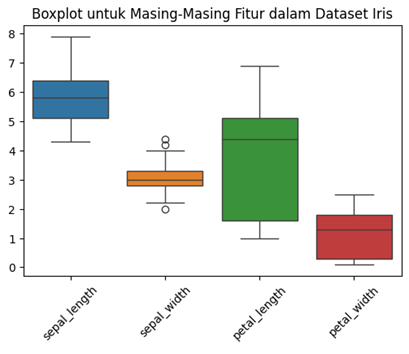

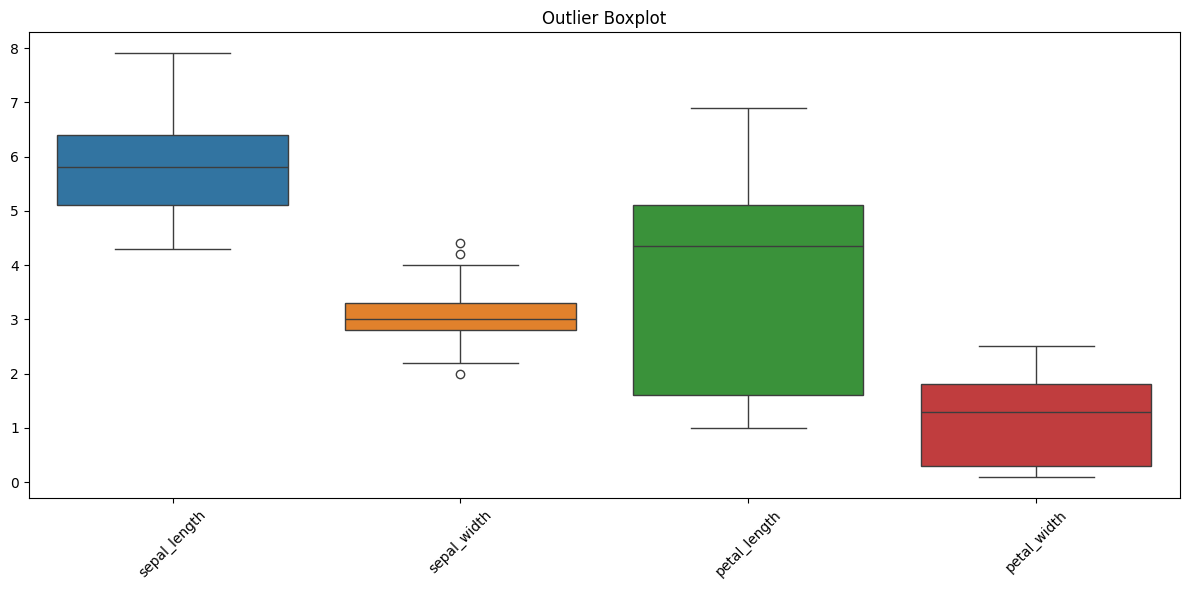

In [320]:
fitur_numerik = data_imputasi.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=data_imputasi[fitur_numerik])
plt.xticks(rotation=45)
plt.title("Outlier Boxplot")
plt.tight_layout()
plt.show()

Coba cari *outlier* dengan kode Python

In [321]:
Q1 = np.percentile(data_imputasi[fitur_numerik], 25)
Q3 = np.percentile(data_imputasi[fitur_numerik], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_imputasi[fitur_numerik][(data_imputasi[fitur_numerik] < lower_bound) | (data_imputasi[fitur_numerik] > upper_bound)]

print(f"jumlah outlier: {outliers.count().sum()}")


jumlah outlier: 0


### 5) Normalisasi MinMax
Normalisasi bertujuan menyamakan rentang nilai pada setiap fitur. Beberapa metode pembelajaran mesin memiliki kinerja yang buruk apabila rentang nilai tiap variabel berbeda jauh.

Sebelum melakukan normalisasi, cek terlebih dahulu rentang (nilai max - nilai min) pada masing masing fitur

In [322]:
def cetak_rentang(df_input):
    for column in df_input.columns:
        min_val = df_input[column].min()
        max_val = df_input[column].max()
        rentang = max_val - min_val
        print(f"Rentang nilai {column}: {rentang}")

In [323]:
cetak_rentang(data_imputasi[fitur_numerik])

Rentang nilai sepal_length: 3.6000000000000005
Rentang nilai sepal_width: 2.4000000000000004
Rentang nilai petal_length: 5.9
Rentang nilai petal_width: 2.4


Terlihat bahwa masing-masing fitur memiliki rentang yang berbeda, meskipun tidak terlalu signifikan. Pada praktikum ini Anda akan mengimplementasikan normalisasi MinMax untuk menyamakan rentang setiap fitur menjadi satu (1). Persamaan dari fungsi normalisasi MinMax adalah sebagai berikut:

$x'=\frac{x-min(x)}{max(x)-min(x)}$

dimana $x'$ merupakan nilai ternormalisasi, $x$ adalah nilai asal, $min(x)$ merupakan nilai minimum pada suatu fitur, dan $max(x)$ merupakan nilai maksimum pada suatu fitur.

Implementasikan metode normalisasi MinMax pada fungsi bernama **minmax**.


In [324]:
def minmax(data):
    min_val = min(data)
    max_val = max(data)
    normalized_data = [(x - min_val) / (max_val - min_val) for x in data]
    return normalized_data

Buatlah sebuah dataframe baru bernama **data_normal** yang berisi hasil dari metode minmax dengan input **data_imputasi**

In [325]:
data_normal = data_imputasi[fitur_numerik].apply(minmax)

Cek 5 baris pertama **data_normal**

In [326]:
data_normal.head()

,sepal_length,sepal_width,petal_length,petal_width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.199074,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


Tampilkan rentang masing-masing fitur menggunakan fungsi **cetak_rentang** yang telah dibuat

In [327]:
for fitur in fitur_numerik:
        cetak_rentang(data_normal[[fitur]])

Rentang nilai sepal_length: 1.0
Rentang nilai sepal_width: 1.0
Rentang nilai petal_length: 1.0
Rentang nilai petal_width: 1.0


### 6) Label Encoding

Lakukan *label encoding* pada variabel target "Species", sehingga nantinya misalnya Iris setosa menjadi 0, versicolor menjadi 1, virginica menjadi 2

In [328]:
def label_encoding(x):
    label_map = {
        'Iris-setosa': 0, 
        'Iris-versicolor': 1, 
        'Iris-virginica': 2
    }
    return label_map.get(x, x)

data_normal['Species'] = data['Species'].apply(label_encoding)

Tampilkan hasil DataFrame pada 10 data pertama dan terakhir menggunakan `head()` dan `tail()`

In [329]:
print(data_normal.head(10))
print(data_normal.tail(10))

   sepal_length  sepal_width  petal_length  petal_width  Species
0      0.222222     0.625000      0.067797     0.041667        0
1      0.166667     0.416667      0.067797     0.041667        0
2      0.199074     0.500000      0.050847     0.041667        0
3      0.083333     0.458333      0.084746     0.041667        0
4      0.194444     0.666667      0.067797     0.041667        0
5      0.305556     0.791667      0.118644     0.125000        0
6      0.083333     0.583333      0.067797     0.083333        0
7      0.194444     0.583333      0.084746     0.041667        0
8      0.027778     0.375000      0.067797     0.041667        0
9      0.166667     0.458333      0.084746     0.000000        0
     sepal_length  sepal_width  petal_length  petal_width  Species
140      0.666667     0.458333      0.779661     0.958333        2
141      0.722222     0.458333      0.694915     0.916667        2
142      0.416667     0.291667      0.694915     0.750000        2
143      0.694444

## TUGAS
1. Implementasikan metode normalisasi Z-score dengan cara membuat fungsi bernama **zscore**.
2. Normalisasikan dataframe **data_imputasi** menggunakan fungsi **zscore**. Simpan hasilnya pada dataframe bernama **data_zscore**.
3. Jelaskan perbedaan hasil normalisasi **MinMax** dan **ZScore**. Petunjuk : cek nilai rentang, rata-rata dan standar deviasi dari **data_zscore**.


In [330]:
def zscore(df_input):
    df_output = (df_input - df_input.mean()) / df_input.std()
    return df_output


In [331]:
data_zscore = zscore(data_imputasi[fitur_numerik])

In [332]:
def minmax(data):
    min_val = min(data)
    max_val = max(data)
    normalized_data = [(x - min_val) / (max_val - min_val) for x in data]
    return normalized_data

In [333]:
data_minmax = data_imputasi[fitur_numerik].apply(minmax)

In [334]:
print(data_zscore.head())
print(data_minmax.head())
print(cetak_rentang(data_zscore))
print(cetak_rentang(data_minmax))
print(data_zscore.describe())
print(data_minmax.describe())

   sepal_length  sepal_width  petal_length  petal_width
0     -0.907825     1.053430     -1.336763    -1.312509
1     -1.152507    -0.110540     -1.336763    -1.312509
2     -1.009776     0.355048     -1.393408    -1.312509
3     -1.519530     0.122254     -1.280117    -1.312509
4     -1.030166     1.286224     -1.336763    -1.312509
   sepal_length  sepal_width  petal_length  petal_width
0      0.222222     0.625000      0.067797     0.041667
1      0.166667     0.416667      0.067797     0.041667
2      0.199074     0.500000      0.050847     0.041667
3      0.083333     0.458333      0.084746     0.041667
4      0.194444     0.666667      0.067797     0.041667
Rentang nilai sepal_length: 4.4042740717592395
Rentang nilai sepal_width: 5.587057312242887
Rentang nilai petal_length: 3.342099429860446
Rentang nilai petal_width: 3.160938725348725
None
Rentang nilai sepal_length: 1.0
Rentang nilai sepal_width: 1.0
Rentang nilai petal_length: 1.0
Rentang nilai petal_width: 1.0
None
       se

Tuliskan jawaban pertanyaan nomor 3 **di sini**

Perbedaan hasil normalisasi MinMax dan Z-Score:

1. Rentang nilai: Z-Score berkisar -2.4 hingga 3.1, sementara MinMax selalu 0 sampai 1.

2. Rata-rata: Z-Score mendekati 0 untuk semua fitur, MinMax bervariasi antara 0.42-0.47.

3. Simpangan baku: Z-Score selalu 1, MinMax bervariasi antara 0.18-0.32.

4. Interpretasi: Z-Score menunjukkan jarak nilai dari rata-rata dalam standar deviasi, MinMax menunjukkan posisi relatif nilai dalam rentang aslinya.

5. Sensitivitas terhadap outlier: Z-Score lebih tahan, MinMax lebih sensitif karena bergantung pada nilai ekstrem.

Kedua metode memiliki kelebihan masing-masing tergantung kebutuhan analisis dan karakteristik data. Misalnya, Z-Score lebih tahan terhadap outlier, sedangkan MinMax lebih sensitif karena bergantung pada nilai ekstrem.